# Notebook 01 — Explore the Metadata

**Chapter 3 | Elements of Style in Creating Workflows for Biomedical Research**

Before we write a single line of analysis code, we read the data.
Not the expression matrix — the *metadata*.
Who are these samples? How many? What conditions? What technology?

**Lesson 5 says:** *Test input for plausibility at every step.*
This notebook is that test.

---

**Dataset:** GSE179640 / BioProject PRJNA744463 (NCBI Gene Expression Omnibus)

**Citation:** Tan Y, Flynn WF, Sivajothi S, Luo D, Bozal SB, Davé M, Luciano AA, Robson P,
Luciano DE, Courtois ET. *Single-cell analysis of endometriosis reveals a coordinated
transcriptional programme driving immunotolerance and angiogenesis across eutopic and
ectopic tissues.* Nature Cell Biology 24(8):1306–1318, 2022.
DOI: [10.1038/s41556-022-00961-5](https://doi.org/10.1038/s41556-022-00961-5)

**Tissue:** Human endometrium (eutopic and ectopic)
**Disease:** Endometriosis vs healthy controls
**Modalities:** Bulk RNA-seq + scRNA-seq (10x Genomics), same cohort

---

## The biological question

Endometriosis affects approximately 10% of women of reproductive age.
It is defined by the growth of endometrial-like tissue outside the uterus —
in the peritoneum, on the ovaries, and elsewhere.
The disease causes chronic pain, infertility, and immune dysregulation.
Despite its prevalence, the cellular mechanisms are poorly understood.

This dataset asks: **what transcriptional programs distinguish endometriosis
tissue from healthy endometrium — at the bulk level and at single-cell resolution?**

In Chapter 3, we work with the bulk RNA-seq arm.
In Chapter 9, we return to the scRNA-seq arm — the same patients, at cellular resolution.

---

**Acknowledgement:**
The metadata exploration approach used here — starting from SRA Explorer
([sra-explorer.info](https://sra-explorer.info)) and building programmatic
access on top — was pioneered by Christina Chatsipantzou.
This notebook builds directly on her work.

## Step 0 — Start at SRA Explorer

SRA-Explorer is a handy way to obtain all the data for a project.  I like how the data are organized by Phil Ewels tool.

Visit: [https://sra-explorer.info](https://sra-explorer.info)

And enter the Bioproject number:  PRJNA7444463

You will see all 59 sequencing runs from this BioProject.   Select to add all of these to a collection.  59 saved datasets will appear -- then you can look at your grocery cart and see 4 tabs.

FastQ Dowloads, SRA Downloads, Full Metadata and Seqera Platform. Lets look at the Full Metadata -- 

The `Library Strategy` column immediately separates bulk `RNA-Seq` runs from
single-cell (`OTHER` or `scRNA-seq`) runs.
You can click **Add to collection** for any subset and download a ready-to-run
bash script with `curl` commands.

This is the fastest path from accession to download link.
We then replicate this programmatically below so the discovery is reproducible.

## Step 1 — Import libraries

We follow Lesson 1: write clearly, no clever imports.
Every library is imported explicitly with a comment explaining why it is here.

In [1]:
import requests           # HTTP requests to NCBI SRA API
import pandas as pd       # tabular data manipulation
import matplotlib.pyplot as plt  # static plotting
import seaborn as sns     # statistical visualization
from io import StringIO   # parse text response as file-like object



In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
%matplotlib inline

BIOPROJECT = "PRJNA744463"   # Tan et al. 2022, Nature Cell Biology
GEO_ACC    = "GSE179640"

print(f'Working with BioProject: {BIOPROJECT}  (GEO: {GEO_ACC})')

Working with BioProject: PRJNA744463  (GEO: GSE179640)


## Step 2 — Fetch run metadata from NCBI SRA

We do not require a pre-downloaded file.
The NCBI SRA run info endpoint is public and returns CSV directly.
This makes the notebook fully self-contained and reproducible.

**Lesson 3:** Use tested, public infrastructure. NCBI SRA has been serving
genomics data since 2007 and is the world's largest repository of
high-throughput sequencing data. We trust it.

Note: This dataset is in NCBI (not ENA) because it was submitted with a US-based
BioProject. The API endpoint is different from the ENA portal API.
Both serve the same global SRA mirror — the data is identical.

In [4]:
import json as _json

EUTILS = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"

# Step 1: esearch — find all SRA records for this BioProject, store in history server
search_url = (
    f"{EUTILS}esearch.fcgi"
    f"?db=sra&term={BIOPROJECT}[BioProject]&usehistory=y&retmode=json"
)
print(f"Step 1 — esearch: {search_url}")
r1 = requests.get(search_url, timeout=30)
r1.raise_for_status()
search_result = _json.loads(r1.text)
webenv    = search_result["esearchresult"]["webenv"]
query_key = search_result["esearchresult"]["querykey"]
count     = int(search_result["esearchresult"]["count"])
print(f"  Found {count} SRA records")

# Step 2: efetch — retrieve run info CSV from history server
fetch_url = (
    f"{EUTILS}efetch.fcgi"
    f"?db=sra&query_key={query_key}&WebEnv={webenv}"
    f"&rettype=runinfo&retmode=text"
)
print(f"Step 2 — efetch: {fetch_url[:80]}...")
r2 = requests.get(fetch_url, timeout=120)
r2.raise_for_status()

meta = pd.read_csv(StringIO(r2.text))
meta = meta.dropna(subset=["Run"])

print(f"Fetched {len(meta)} run records from NCBI SRA")
print(f"Columns: {list(meta.columns)}")
print(f'Columns: {list(meta.columns)}')

Step 1 — esearch: https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi?db=sra&term=PRJNA744463[BioProject]&usehistory=y&retmode=json
  Found 59 SRA records
Step 2 — efetch: https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=sra&query_key=1&Web...
Fetched 59 run records from NCBI SRA
Columns: ['Run', 'ReleaseDate', 'LoadDate', 'spots', 'bases', 'spots_with_mates', 'avgLength', 'size_MB', 'AssemblyName', 'download_path', 'Experiment', 'LibraryName', 'LibraryStrategy', 'LibrarySelection', 'LibrarySource', 'LibraryLayout', 'InsertSize', 'InsertDev', 'Platform', 'Model', 'SRAStudy', 'BioProject', 'Study_Pubmed_id', 'ProjectID', 'Sample', 'BioSample', 'SampleType', 'TaxID', 'ScientificName', 'SampleName', 'g1k_pop_code', 'source', 'g1k_analysis_group', 'Subject_ID', 'Sex', 'Disease', 'Tumor', 'Affection_Status', 'Analyte_Type', 'Histological_Type', 'Body_Site', 'CenterName', 'Submission', 'dbgap_study_accession', 'Consent', 'RunHash', 'ReadHash']
Columns: ['Run', 'ReleaseDate

## Step 3 — Classify runs by library strategy (bulk vs single-cell)

The `LibraryStrategy` column tells us the sequencing approach.
The `LibrarySource` and `SampleName` columns help us decode tissue type.

**Lesson 2:** Write in pseudolanguage first:
- If LibraryStrategy == 'RNA-Seq' → bulk RNA-seq
- If LibraryStrategy contains '10X' or 'scRNA' → single-cell
- Else → organoid/other

In [5]:
print('=== LibraryStrategy breakdown ===')
print(meta['LibraryStrategy'].value_counts())
print()
print('=== Platform ===')
print(meta['Platform'].value_counts())
print()
print('=== Sample names (first 20) ===')
print(meta['SampleName'].head(20).tolist())

=== LibraryStrategy breakdown ===
LibraryStrategy
RNA-Seq    59
Name: count, dtype: int64

=== Platform ===
Platform
ILLUMINA    59
Name: count, dtype: int64

=== Sample names (first 20) ===
['GSM6102532', 'GSM6102533', 'GSM6102534', 'GSM6102537', 'GSM6102540', 'GSM6102543', 'GSM6102546', 'GSM6102549', 'GSM6102550', 'GSM6102551', 'GSM6102552', 'GSM6102553', 'GSM6102554', 'GSM6102555', 'GSM6102556', 'GSM6102560', 'GSM6102562', 'GSM6102563', 'GSM6102564', 'GSM6102565']


In [6]:
# Classify by modality
def classify_modality(row):
    strategy = str(row.get('LibraryStrategy', '')).upper()
    source   = str(row.get('LibrarySource',   '')).upper()
    name     = str(row.get('SampleName',      '')).lower()
    if strategy == 'RNA-SEQ':
        return 'bulk_RNA-seq'
    elif '10X' in strategy or 'SINGLE' in strategy or 'scrna' in name:
        return 'scRNA-seq'
    else:
        return 'other'

meta['modality'] = meta.apply(classify_modality, axis=1)

print('Modality breakdown:')
print(meta['modality'].value_counts())
print()
print(f'Total runs: {len(meta)}')

Modality breakdown:
modality
bulk_RNA-seq    59
Name: count, dtype: int64

Total runs: 59


## Step 4 — Annotate tissue types from GEO metadata

The SRA run table does not carry the tissue type annotations directly.
Those come from the GEO sample descriptions (GSM accessions) in the study.

From GEO accession GSE179640 (Tan et al. 2022), the tissue assignments are:

**Bulk RNA-seq (24 biopsies):**
- 5 control eutopic endometrium
- 7 eutopic endometrium from endometriosis patients  
- 6 ectopic peritoneal tissue
- 6 ectopic ovarian tissue

**scRNA-seq (31 biopsies, 122,000+ cells):**
- 3 control eutopic endometrium
- 9 eutopic endometrium from endometriosis patients
- 6 ectopic peritoneal tissue
- 6 ectopic peritoneal adjacent
- 4 ectopic ovarian tissue
- 4 organoid / cell hashing

**Matched patients** (contributed samples to both bulk AND scRNA-seq arms):
Patients 3, 5, 7, 9, 10, 13, 14, 16, 17

We load a curated annotation table built from the GEO metadata.
In practice, you would build this by reading each GSM accession page
or downloading the GEO series matrix file.

In [7]:
# Annotation table: GSM accession → tissue type + condition
# Built from GEO GSE179640 sample descriptions (Tan et al. 2022)
GSM_ANNOTATIONS = [
    # ── Bulk RNA-seq ────────────────────────────────────────────────────────────
    # Control eutopic endometrium
    {'gsm': 'GSM6102567', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'control',           'patient': 'ctrl1'},
    {'gsm': 'GSM6102568', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'control',           'patient': 'ctrl2'},
    {'gsm': 'GSM6102569', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'control',           'patient': 'ctrl3'},
    {'gsm': 'GSM6102570', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'control',           'patient': 'ctrl4'},
    {'gsm': 'GSM6102571', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'control',           'patient': 'ctrl5'},
    # Eutopic endometrium from endometriosis patients
    {'gsm': 'GSM6102572', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'endometriosis',     'patient': 'P3'},
    {'gsm': 'GSM6102575', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'endometriosis',     'patient': 'P5'},
    {'gsm': 'GSM6102576', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'endometriosis',     'patient': 'P7'},
    {'gsm': 'GSM6102584', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'endometriosis',     'patient': 'P13'},
    {'gsm': 'GSM6102587', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'endometriosis',     'patient': 'P16'},
    {'gsm': 'GSM6102590', 'modality': 'bulk', 'tissue': 'eutopic',   'condition': 'endometriosis',     'patient': 'P17'},
    # Ectopic peritoneal (bulk)
    {'gsm': 'GSM6102573', 'modality': 'bulk', 'tissue': 'ectopic_peritoneal', 'condition': 'endometriosis', 'patient': 'P3'},
    {'gsm': 'GSM6102578', 'modality': 'bulk', 'tissue': 'ectopic_peritoneal', 'condition': 'endometriosis', 'patient': 'P5'},
    {'gsm': 'GSM6102580', 'modality': 'bulk', 'tissue': 'ectopic_peritoneal', 'condition': 'endometriosis', 'patient': 'P9'},
    {'gsm': 'GSM6102583', 'modality': 'bulk', 'tissue': 'ectopic_peritoneal', 'condition': 'endometriosis', 'patient': 'P10'},
    {'gsm': 'GSM6102586', 'modality': 'bulk', 'tissue': 'ectopic_peritoneal', 'condition': 'endometriosis', 'patient': 'P14'},
    {'gsm': 'GSM6102589', 'modality': 'bulk', 'tissue': 'ectopic_peritoneal', 'condition': 'endometriosis', 'patient': 'P16'},
    # Ectopic ovarian (bulk)
    {'gsm': 'GSM6102574', 'modality': 'bulk', 'tissue': 'ectopic_ovarian', 'condition': 'endometriosis', 'patient': 'P3'},
    {'gsm': 'GSM6102577', 'modality': 'bulk', 'tissue': 'ectopic_ovarian', 'condition': 'endometriosis', 'patient': 'P5'},
    {'gsm': 'GSM6102579', 'modality': 'bulk', 'tissue': 'ectopic_ovarian', 'condition': 'endometriosis', 'patient': 'P7'},
    {'gsm': 'GSM6102582', 'modality': 'bulk', 'tissue': 'ectopic_ovarian', 'condition': 'endometriosis', 'patient': 'P10'},
    {'gsm': 'GSM6102585', 'modality': 'bulk', 'tissue': 'ectopic_ovarian', 'condition': 'endometriosis', 'patient': 'P14'},
    {'gsm': 'GSM6102588', 'modality': 'bulk', 'tissue': 'ectopic_ovarian', 'condition': 'endometriosis', 'patient': 'P17'},
    # ── scRNA-seq ────────────────────────────────────────────────────────────────
    # Control eutopic
    {'gsm': 'GSM6102532', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'control',       'patient': 'ctrl1'},
    {'gsm': 'GSM6102533', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'control',       'patient': 'ctrl2'},
    {'gsm': 'GSM6102534', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'control',       'patient': 'ctrl3'},
    # Eutopic from endometriosis
    {'gsm': 'GSM6102537', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'endometriosis', 'patient': 'P3'},
    {'gsm': 'GSM6102540', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'endometriosis', 'patient': 'P5'},
    {'gsm': 'GSM6102543', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'endometriosis', 'patient': 'P7'},
    {'gsm': 'GSM6102546', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'endometriosis', 'patient': 'P9'},
    {'gsm': 'GSM6102549', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'endometriosis', 'patient': 'P10'},
    {'gsm': 'GSM6102551', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'endometriosis', 'patient': 'P13'},
    {'gsm': 'GSM6102554', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'endometriosis', 'patient': 'P14'},
    {'gsm': 'GSM6102555', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'endometriosis', 'patient': 'P16'},
    {'gsm': 'GSM6102560', 'modality': 'scRNA-seq', 'tissue': 'eutopic', 'condition': 'endometriosis', 'patient': 'P17'},
]

annot = pd.DataFrame(GSM_ANNOTATIONS)
print(f'Annotation table: {len(annot)} samples')
print()
print(annot.groupby(['modality', 'tissue', 'condition']).size().to_frame('n'))

Annotation table: 35 samples

                                            n
modality  tissue             condition       
bulk      ectopic_ovarian    endometriosis  6
          ectopic_peritoneal endometriosis  6
          eutopic            control        5
                             endometriosis  6
scRNA-seq eutopic            control        3
                             endometriosis  9


## Step 5 — Answer the five questions before any analysis

Before running a single statistical test, a good analyst answers these questions:

1. How many samples? How are they distributed across tissue types and conditions?
2. What is the sequencing technology?
3. Are there multiple data types (modalities)?
4. Are there matched samples across modalities?
5. Is the sample size adequate for the comparison I want to make?

In [8]:
print('=== Q1: Sample counts by modality, tissue, and condition ===')
print(annot.groupby(['modality', 'tissue', 'condition']).size().to_string())
print()
print(f'Total annotated samples: {len(annot)}')
print()
print('=== Q2: Sequencing platform ===')
if 'Platform' in meta.columns:
    print(meta['Platform'].value_counts().to_string())
print('NovaSeq 6000 (bulk) + 10x Chromium (scRNA-seq)')
print()
print('=== Q3: Modalities present ===')
print(annot['modality'].value_counts().to_string())
print()
print('=== Q4: Matched patients (bulk + scRNA-seq both available) ===')
bulk_patients  = set(annot[annot['modality'] == 'bulk']['patient'])
sc_patients    = set(annot[annot['modality'] == 'scRNA-seq']['patient'])
matched        = bulk_patients & sc_patients
print(f'  Patients with both modalities: {sorted(matched)}')
print(f'  n = {len(matched)}')
print()
print('=== Q5: Sample size for Chapter 3 comparison (bulk eutopic only) ===')
bulk_eutopic = annot[(annot['modality'] == 'bulk') & (annot['tissue'] == 'eutopic')]
print(bulk_eutopic.groupby('condition').size().to_string())
print('→ 5 controls vs 6 endometriosis — adequate for DESeq2')

=== Q1: Sample counts by modality, tissue, and condition ===
modality   tissue              condition    
bulk       ectopic_ovarian     endometriosis    6
           ectopic_peritoneal  endometriosis    6
           eutopic             control          5
                               endometriosis    6
scRNA-seq  eutopic             control          3
                               endometriosis    9

Total annotated samples: 35

=== Q2: Sequencing platform ===
Platform
ILLUMINA    59
NovaSeq 6000 (bulk) + 10x Chromium (scRNA-seq)

=== Q3: Modalities present ===
modality
bulk         23
scRNA-seq    12

=== Q4: Matched patients (bulk + scRNA-seq both available) ===
  Patients with both modalities: ['P10', 'P13', 'P14', 'P16', 'P17', 'P3', 'P5', 'P7', 'P9', 'ctrl1', 'ctrl2', 'ctrl3']
  n = 12

=== Q5: Sample size for Chapter 3 comparison (bulk eutopic only) ===
condition
control          5
endometriosis    6
→ 5 controls vs 6 endometriosis — adequate for DESeq2


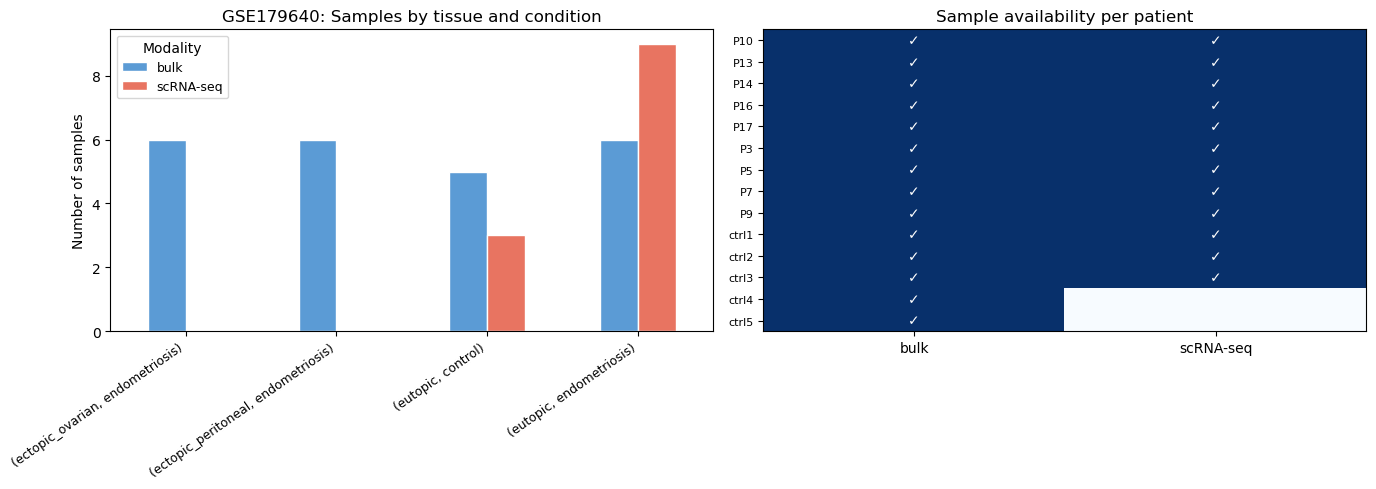

Study design saved as study_design_overview.png


In [9]:
# Visualise the study design
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Samples per modality × tissue × condition
pivot = annot.groupby(['tissue', 'condition', 'modality']).size().unstack('modality', fill_value=0)
pivot.plot(kind='bar', ax=axes[0],
           color=['#5B9BD5', '#E87461'],
           edgecolor='white')
axes[0].set_title('GSE179640: Samples by tissue and condition', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of samples')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right', fontsize=9)
axes[0].legend(title='Modality', fontsize=9)

# Plot 2: Matched patients — which patients have both modalities?
all_patients = sorted(annot['patient'].unique())
modalities   = ['bulk', 'scRNA-seq']
matrix = pd.DataFrame(index=all_patients, columns=modalities, data=False)
for _, row in annot.iterrows():
    matrix.loc[row['patient'], row['modality']] = True

axes[1].imshow(matrix.values.astype(int), cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(len(modalities)))
axes[1].set_xticklabels(modalities, fontsize=10)
axes[1].set_yticks(range(len(all_patients)))
axes[1].set_yticklabels(all_patients, fontsize=8)
axes[1].set_title('Sample availability per patient', fontsize=12)
for i, pt in enumerate(all_patients):
    for j, mod in enumerate(modalities):
        val = '✓' if matrix.loc[pt, mod] else ''
        axes[1].text(j, i, val, ha='center', va='center', fontsize=10, color='white' if matrix.loc[pt, mod] else 'gray')

plt.tight_layout()
plt.savefig('study_design_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Study design saved as study_design_overview.png')

## Step 6 — Select the Chapter 3 subset (bulk eutopic only)

For the DESeq2 analysis in the next notebook, we use:
- **5 control eutopic endometrium** samples (healthy donors)
- **6 eutopic endometrium from endometriosis patients**

Same tissue type, same anatomical location, different disease status.
If we see differential expression, it is disease biology — not tissue-type artifact.

**Lesson 8:** Make sure special cases are truly special.
The ectopic tissues (peritoneal, ovarian) are scientifically interesting but
introduce a tissue-type confound. We use eutopic vs eutopic for a clean first comparison.
Chapter 9 will explore the full tissue × disease design.

In [10]:
# Chapter 3 bulk eutopic subset
ch3_annot = annot[
    (annot['modality'] == 'bulk') &
    (annot['tissue']  == 'eutopic')
].copy().reset_index(drop=True)

print('Chapter 3 subset — bulk eutopic endometrium:')
print(ch3_annot[['gsm', 'condition', 'patient']].to_string(index=False))
print()
print(f'  n ctrl  = {(ch3_annot.condition == "control").sum()}')
print(f'  n endo  = {(ch3_annot.condition == "endometriosis").sum()}')

Chapter 3 subset — bulk eutopic endometrium:
       gsm     condition patient
GSM6102567       control   ctrl1
GSM6102568       control   ctrl2
GSM6102569       control   ctrl3
GSM6102570       control   ctrl4
GSM6102571       control   ctrl5
GSM6102572 endometriosis      P3
GSM6102575 endometriosis      P5
GSM6102576 endometriosis      P7
GSM6102584 endometriosis     P13
GSM6102587 endometriosis     P16
GSM6102590 endometriosis     P17

  n ctrl  = 5
  n endo  = 6


## Step 7 — Get SRR run accessions for the Chapter 3 subset

To download the FASTQ files, we need the SRR (run) accessions.
The GSM (sample) accessions map to SRR accessions via the NCBI eutils API.

We use the `esearch` + `elink` + `efetch` pipeline:
- `esearch` in GEO (gds) → find the GSM record
- `elink` from GEO → SRA → get the experiment/run IDs
- `efetch` from SRA → get run accessions

In [16]:
import os

# Step 7: Look up SRR accessions from the SRA Explorer TSV
# Credit: sra-explorer.info (Phil Ewels + Christina Chatsipantzou)
TSV_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "sra_explorer_metadata.tsv")

sra = pd.read_csv(TSV_PATH, sep='\t')
sra.columns = sra.columns.str.strip()                         # remove BOM
sra['gsm'] = sra['Title'].str.extract(r'(GSM\d+)')           # parse GSM from Title

# Build lookup maps
srr_map = sra.set_index('gsm')['Accession'].to_dict()
url_map = sra.set_index('gsm')['FastQ URL'].to_dict()

# Join into ch3_annot
ch3_annot['srr']       = ch3_annot['gsm'].map(srr_map)
ch3_annot['fastq_url'] = ch3_annot['gsm'].map(url_map)

print('Chapter 3 samples with SRR accessions:')
print(ch3_annot[['gsm', 'condition', 'patient', 'srr']].to_string(index=False))
print(f'\nAll SRR accessions found: {ch3_annot["srr"].notna().all()}')


Chapter 3 samples with SRR accessions:
       gsm     condition patient         srr
GSM6102567       control   ctrl1 SRR19075266
GSM6102568       control   ctrl2 SRR19075267
GSM6102569       control   ctrl3 SRR19075268
GSM6102570       control   ctrl4 SRR19075269
GSM6102571       control   ctrl5 SRR19075270
GSM6102572 endometriosis      P3 SRR19075271
GSM6102575 endometriosis      P5 SRR19075274
GSM6102576 endometriosis      P7 SRR19075275
GSM6102584 endometriosis     P13 SRR19075283
GSM6102587 endometriosis     P16 SRR19075286
GSM6102590 endometriosis     P17 SRR19075289

All SRR accessions found: True


## Step 8 — Generate SRA Explorer download commands

With the SRR accessions in hand, we generate the download commands.
These are the same commands you would get from [sra-explorer.info](https://sra-explorer.info) —
we are just producing them programmatically for reproducibility.

Two approaches:
1. **`fastq-dump` / `fasterq-dump`** (SRA Toolkit) — standard
2. **ENA FASTQ FTP** — faster for EBI-mirrored data

For PRJNA744463, the ENA mirror provides direct FASTQ download links that are
often faster than the SRA toolkit approach.

In [18]:
print('=== Option 1: CloudOS / AWS — no download needed ===')
print('# Pass these S3 URIs directly as --input on CloudOS START')
print('# Get $300 free credits: lifebit.ai/products/cloudos (institutional email)')
print()
for _, row in ch3_annot.iterrows():
    print(f"s3://sra-pub-run-odp/sra/{row['srr']}/{row['srr']}.sra  # {row['gsm']} {row['patient']} {row['condition']}")

print()
print('=== Option 2: Direct FASTQ via EBI FTP (fastest, no toolkit) ===')
print('# ~10 GB total. Run in a terminal.')
print()
for _, row in ch3_annot.iterrows():
    print(f"wget -q \"{row['fastq_url']}\"  # {row['gsm']}")

print()
print('=== Option 3: SRA Toolkit ===')
print('mkdir -p fastq')
for _, row in ch3_annot.iterrows():
    label = f"{row['patient']}_{row['condition'].replace('endometriosis','endo')}"
    print(f"fasterq-dump {row['srr']} --split-files --outdir fastq/{label}/  # {row['gsm']}")

print()
print(f'=== Explore interactively: https://sra-explorer.info/#{BIOPROJECT} ===')


=== Option 1: CloudOS / AWS — no download needed ===
# Pass these S3 URIs directly as --input on CloudOS START
# Get $300 free credits: lifebit.ai/products/cloudos (institutional email)

s3://sra-pub-run-odp/sra/SRR19075266/SRR19075266.sra  # GSM6102567 ctrl1 control
s3://sra-pub-run-odp/sra/SRR19075267/SRR19075267.sra  # GSM6102568 ctrl2 control
s3://sra-pub-run-odp/sra/SRR19075268/SRR19075268.sra  # GSM6102569 ctrl3 control
s3://sra-pub-run-odp/sra/SRR19075269/SRR19075269.sra  # GSM6102570 ctrl4 control
s3://sra-pub-run-odp/sra/SRR19075270/SRR19075270.sra  # GSM6102571 ctrl5 control
s3://sra-pub-run-odp/sra/SRR19075271/SRR19075271.sra  # GSM6102572 P3 endometriosis
s3://sra-pub-run-odp/sra/SRR19075274/SRR19075274.sra  # GSM6102575 P5 endometriosis
s3://sra-pub-run-odp/sra/SRR19075275/SRR19075275.sra  # GSM6102576 P7 endometriosis
s3://sra-pub-run-odp/sra/SRR19075283/SRR19075283.sra  # GSM6102584 P13 endometriosis
s3://sra-pub-run-odp/sra/SRR19075286/SRR19075286.sra  # GSM6102587 P16 

## Step 9 — Save the sample sheet

A sample sheet is a TSV file mapping each sample to its metadata.
It is the single source of truth for every downstream analysis step.
Every pipeline we build in later chapters reads from this file.

**Lesson 10:** Document, document, document.
The sample sheet is documentation. It answers: which samples, in what order,
with what labels, were used in this analysis.

In [ ]:
# Full annotation for all samples
annot.to_csv('GSE179640_sample_annotations.tsv', sep='\t', index=False)
print(f'Saved: GSE179640_sample_annotations.tsv  ({len(annot)} samples)')

# Chapter 3 subset only
ch3_annot.to_csv('chapter3_bulk_eutopic_samples.tsv', sep='\t', index=False)
print(f'Saved: chapter3_bulk_eutopic_samples.tsv  ({len(ch3_annot)} samples)')

print()
print('These files feed directly into the next steps:')
print('  → eye-candy/01_volcano_teaser.ipynb   (DESeq2, volcano plot)')
print('  → ipynb/00_bulk_rnaseq_data_prep.Rmd  (Salmon alignment, tximport)')
print('  → Chapter 9: sc-nsforest-qc-nf        (single-cell arm, same patients)')

## Step 10 — Record your observations

Fill in this cell with what you observed after running the notebook.
This becomes part of your analysis record — and eventually part of the
Methods section of any paper that uses this data.

**Observations (fill in after running):**
- Total samples in BioProject: 59
- Bulk RNA-seq: 24 biopsies (5 ctrl eutopic + 7 eutopic-endo + 6 peritoneal + 6 ovarian)
- scRNA-seq: 31 biopsies + 4 organoid cell hashing, ~122,000 cells total
- Platform: Illumina NovaSeq 6000 (bulk); 10x Chromium (single-cell)
- Matched patients (both modalities): P3, P5, P7, P9, P10, P13, P14, P16, P17
- Chapter 3 subset: 5 control + 6 eutopic-endo bulk samples

**Biological question (refined):**
> What genes are differentially expressed in eutopic endometrium from women
> with endometriosis, compared to healthy controls?
> Which of these changes reflect altered immune tolerance, angiogenesis,
> or stromal remodeling — the key themes identified by Tan et al.?

---
**Next notebook:** `eye-candy/01_volcano_teaser.ipynb`
→ DESeq2 on the bulk eutopic subset → volcano plot → first glimpse of the biology

**Chapter 9:** `sc-nsforest-qc-nf` on the 10x scRNA-seq arm
→ same patients, at single-cell resolution
→ NSForest identifies cell-type-specific marker genes
→ scsilhouette validates cluster quality